# Regression Disconuity Design - Incumbency Advantage In US Elections

In this notebook I will explain and evaluate regression discontinuity designs for estimating causal effects. To do this I will be replicating a study by Lee (2008). 

Regression discontinuity designs (RDDs) exploit natural experiments in the environment. They rely on the fact that a treatment is performed upon a unit when the attribute of a unit crosses a certain threshold. It is assumed that close to either side of the threshold units are similar with the only difference being whether they received the treatment or not. Therefore, the difference in some variables of interest between the groups close to threshold is the causal effect of the treatment. It can be show that with some reasonable assumption RDD can be as reliable as randomised controlled trials (Lee 2008). How amazing! We can get results as good as RCTs by exploiting some fact about our enviroment. However, a note of caution, for the RDD estimate to be non-biased some assumptions must be true (all of which are not testable) and furthermore, we must interpret the result correctly (see the assumptions and implementation sections below) 

In this notebook we apply RDDs to studying the incumbency advantage. By incumbency advantage we mean the fact that incumbents in the US House Representatives are much more likely to be relected. Lee (2008) states that the relection rate of incumbents is about 90% and has been stable over the last 50 years. RDDs can be applied to study the incumbency advantage because we know the threshold at which a candidate recieves the treatment of being an incumbent, it is when vote count is 50%. Therefore, if the assumptions of RDD hold, then the difference in votes received at the next election by incumbents who just won their district vs candidates who just lost their district in the previous election will give the causal effect of incumbency on vote share received.

Some quick notation for the rest of the notebook. Each inidividual $i$ has a probability of winning the next election of $Y$, if they are the incumbent they receive $Y^{1}$ if not they recieve $Y^{0}$. Each individual also has a set of covariates $X_{i}$ which contains the *running variable* $V_{i}$ (last election vote difference vs the next best party in this context), when $V_{i} > v_{0}$ (last election vote difference vs the next best party is greater than 0) the individual recieves the treatment $W_{i}$ (becomes the incumbent).


# Assumptions, Interpreation & Implementation of RDD

RDDs assume the following (Lemieux & Imbens 2008):

1. $E[Y^{0} | V=v] \text{ and } E[Y^{1} | V=v] \text{ are continous in } v$

2. $F_{Y^{0} | v}(y|v) \text{ and } F_{Y^{1} | v}(y|v) \text{ are continuous in } c$

These assumptions are actually stronger than required as actually we only require continuity at the threshold value $V=v_{0}$. If these assumptions are true they are telling us the individuals just below the threshold are a good counterfactual for individuals just above the threshold. For example, looking at assumption 1, If the conditional expectation of $Y_{0}|V$ is continuous (especially at the threshold) it means we can assume if the individuals who did not recieve the treatment, scored just above $v_{0}$ and still did not recieve the treatment, their outcome would not change much (only by $\frac{dY^{0}|V}{dV}$) and therefore, we assume this is what individuals who score just above threshold would have obtained had they not recieved the treatment.

Note that these assumptions imply that the units should not have perfect control over the value of the running variable. If this was the case we would expect to see a discontinuity in the distribution of the running variable at the threshold. This makes intuitive sense, if unit had perfect control over whether they received the treatment they would self select and therefore they would not be a good counterfacutal for the other. For units to not have complete control some component of the running variables must be down to random chance. If there is an element of random chance, then right at threshold we can assume units are essentially randomly sorted into treatment and control and therefore the RDD is as good as an RCT - how amazing !

Under either of these assumptions we have the following:

$$
E[Y^{0} | V=v] = \lim_{v \uparrow v_{0}}E[Y^{0} | V=v] = \lim_{v \uparrow v_{0}}E[Y^{0} | W_{i}=0,  V=v] = \lim_{v \uparrow v_{0}}E[Y | V=v]
$$
$$
E[Y^{1} | V=v] = \lim_{v \downarrow v_{0}}E[Y^{0} | V=v] = \lim_{v \downarrow v_{0}}E[Y^{1} | W_{i}=1,  V=v] = \lim_{v \downarrow v_{0}}E[Y | V=v]
$$
$$
ATE^{*} = \lim_{v \downarrow v_{0}}E[Y | V=v] - \lim_{v \uparrow v_{0}}E[Y | V=v]
$$

So the estimand of the $ATE^{*}$ is the difference of two regression functions at the threshold point. Note estimand is starred. This is because RDDs do not given us ATE the across all units just for units very close to threshold and the estimate value should be interpretted as such.

When implementing we must remember that by design we do not have any units where we observe $Y^{0} | V=v_{0}$, therefore, in practice we take a bandwith $b$ from the threshold value $v_{0}$ and fit a regression on each dataset ($v_{0} - b \le v \lt v_{0}$ and  $v_{0} \le v \le v_{0} + b$). This leads to the following models at each side of the cutoff

$$
y_{l} = \alpha_{l} + \beta_{l} V + \epsilon
$$
$$
y_{h} = \alpha_{h} + \beta_{h} V + \epsilon
$$

In this model the size of discontinuity is $\alpha_{h} - \alpha_{l}$. This is because the discontinuity is the the point where $V=0$ and therefore, at this point,

$$
y_{h} - y_{l} = \alpha_{h} -  \alpha_{l}
$$

However, we can also create an identical model algebraically that only requires one regression it is,

$$
y = \alpha + \tau W + \beta V + \lambda D V + \epsilon
$$

The coefficient $\tau$ models the size of discontinuity. $\lambda D V$ is required as it allows for a different slope either side of the discontinuity, without this term we would be forcing an identical slope either side and the estimate would be biased


We should check the robustness of our RDDs. For example we can check if:

1. Including other covariates changes the estimates - it shouldn't because we assume at the discontinuity the candidates are as good as randomised into the treatment
2. (Similar to the above) the distribution of covariates are identical just above and below discontinuity
3. Mccrary test - tests if candidates can self select into treatment


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from lee_data import get_data
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures

%load_ext autoreload
%autoreload 2

# Load Data

Data on US congressional elections between 1946-1998 are used. The dataset contains the following columns

- *yearel* - election year
- *myoutcome* - the democrat candidate won
- *second* - the democrat candidate was second
- *myoutcomenext* - the democrat candidate won the following election
- *use* - a flag for if the row should be used in the regression
- *difshare* - the percentage points more votes won by the democrat than the next best candidate
- *difgrp* - a grouping of the difshare
- *mmyoutcomenext* - the percent of the vote won by democrat candidate at the next election
- *mrunagain* - 
- *mofficeexp* - 
- *melectexp* -



In [140]:
df = get_data("individ_final.dta")
df.head()

,yearel,myoutcome,second,myoutcomenext,use,difshare,difgrp,mmyoutcomenext,mrunagain,mofficeexp,melectexp,mpmyoutcomenext,mprunagain,mpofficeexp,mpelectexp
0,1946.0,1.0,NaN,0.0,NaN,0.061488,212.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1946.0,0.0,1.0,0.0,1.0,-0.061488,187.0,0.107143,0.214286,2.053571,2.339286,0.069917,0.285555,0.671483,0.932918
2,1948.0,1.0,NaN,1.0,1.0,0.104869,220.0,0.743590,0.871795,3.256410,3.461539,0.749363,0.869388,2.650860,2.872225
3,1948.0,0.0,1.0,0.0,NaN,-0.104869,179.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1948.0,0.0,NaN,0.0,NaN,-0.535721,92.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Visualise the discontinuity

The scatter plot below clearly visualises the discontinuity in vote share at the next election between candidates who won the previous election (to the right of the black line) and candidates who lost the previous election (to the left of the black line)



Text(0.5, 1.0, 'Incumbency Advantage in US Elections')

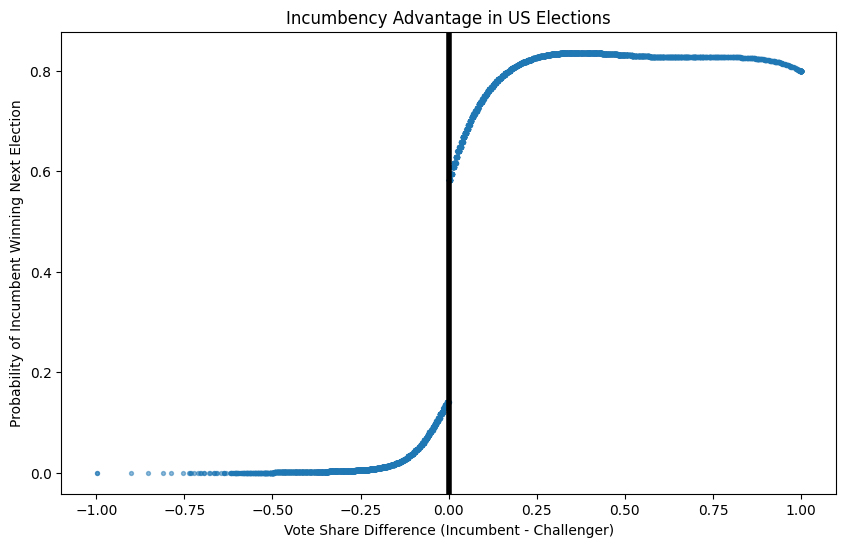

In [198]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['difshare'], df['mpmyoutcomenext'], alpha=0.5, s=8)
ax.axvline(0, color='black', lw=4)
ax.set_xlabel('Vote Share Difference (Incumbent - Challenger)')
ax.set_ylabel('Probability of Incumbent Winning Next Election')
ax.set_title('Incumbency Advantage in US Elections')


# Naive Mean Difference Estimator

Why don't we just compute the difference between average vote share obtained by incumbents against the same value for non-incumbents and call this the incumbency advantage? Well as we can see in the scatter plot above, *vote share* is positive correlated with *probability of the incumbent winning the next election* either side of the discontinuity. This means the probability of a candidate winning the next election increases with vote share at the current election regardless of treatment status - in other words we have selection bias.

The naive mean estimator of the causal impact of incumbency is an increase of $77$ perecentage points in the probability of winning the next election. As shown below, this is large overestimate of the true effect due to the selection bias

In [143]:
print(df[df['difshare'] >= 0]['mpmyoutcomenext'].mean() - df[df['difshare'] < 0]['mpmyoutcomenext'].mean())

0.7695325


# Regression Discontinuity

The incumbency advantage is analyzed at the level of the individual. Specifically I test the causal effect of incumbency on the probability that the incumbent wins the next election. The RDD with a bandwith of $5 \%$ estimates the causal effect of incumbency to be an increase of $44%$ percentage points on the probability of winning the next election. This is very similar to the estimate reported by Lee

In [166]:
df_clean = df[df['use'] == 1]
print(len(df_clean))
df_clean.head()

9674


,yearel,myoutcome,second,myoutcomenext,use,difshare,difgrp,mmyoutcomenext,mrunagain,mofficeexp,melectexp,mpmyoutcomenext,mprunagain,mpofficeexp,mpelectexp
1,1946.0,0.0,1.0,0.0,1.0,-0.061488,187.0,0.107143,0.214286,2.053571,2.339286,0.069917,0.285555,0.671483,0.932918
2,1948.0,1.0,NaN,1.0,1.0,0.104869,220.0,0.743590,0.871795,3.256410,3.461539,0.749363,0.869388,2.650860,2.872225
5,1950.0,1.0,NaN,0.0,1.0,0.164464,232.0,0.853659,0.951219,2.853658,3.121951,0.795229,0.873077,3.329268,3.522228
8,1952.0,1.0,NaN,1.0,1.0,0.079361,215.0,0.773585,0.886792,1.566038,1.641509,0.720720,0.867912,2.324735,2.558522
10,1954.0,1.0,NaN,0.0,1.0,0.139252,227.0,0.846154,0.884615,3.769231,3.980769,0.779348,0.871539,3.063453,3.268021


In [270]:
bandwidth = 0.05
condition = (df_clean['difshare'] >= -bandwidth) & (df_clean['difshare'] <= bandwidth)

In [271]:
df_clean['difshare*myoutcome'] = df_clean['difshare'] * df_clean['myoutcome']

In [272]:
model = sm.OLS(df_clean.loc[condition, 'mpmyoutcomenext'], sm.add_constant(df_clean.loc[condition, ['myoutcome', 'difshare', 'difshare*myoutcome']])).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        mpmyoutcomenext   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.059e+06
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        15:37:01   Log-Likelihood:                 4271.3
No. Observations:                 947   AIC:                            -8535.
Df Residuals:                     943   BIC:                            -8515.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.1435      0.000    546.796      0.000       0.143       0.144
myoutcome              0.4381      0.000   1218.649      0.000       0.437       0.439
difshare               1.2247      0.009    135.981      0.000       1.207       1.242
difshare*myoutcome     0.8074      0.012     66.338      0.000       0.783       0.831
==============================================================================
Omnibus:                        2.598   Durbin-Watson:                   1.958
Prob(Omnibus):                  0.273   Jarque-Bera (JB):                2.450
Skew:                          -0.114   Prob(JB):                        0.294
Kurtosis:                       3.102   Cond. No.                         189.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Robustness Checks

Finally we check the robustness of our RDD. 

1. Firstly, we include mean office experience and mean electoral experience of the democrat candiate in the model. Both of these will be correlated with the probability of winning the next election. However, at the threshold we expect that the response is independent of these variables and therefore out estimate of the causal effect should not change. As you can see the estimate is the same and this test holds.

2. Second, we check that the same two covariates are identical either side of threshold. We actually find with a bandwith 0.05 that the covariates do not share the same distributions. This is to be expected as setting the bandwith to $0.05$ is a biased estimate of limit as the running variable approaches zero. However, we can see that as we continue to reduce the bandwith the difference in means of the covariates approached zero which is what we would expect.

3. Finally we plot the density of the running variable. This should be continuous, especially at the cutoff

## Covariates do not change the estimate

In [273]:
model_with_covars = sm.OLS(df_clean.loc[condition, 'mpmyoutcomenext'], sm.add_constant(df_clean.loc[condition, ['myoutcome', 'difshare', 'difshare*myoutcome', 'mofficeexp', 'melectexp']])).fit()
model_with_covars.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        mpmyoutcomenext   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.841e+06
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        15:37:13   Log-Likelihood:                 4273.8
No. Observations:                 947   AIC:                            -8536.
Df Residuals:                     941   BIC:                            -8507.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.1427      0.001    201.868      0.000       0.141       0.144
myoutcome              0.4381      0.000   1018.110      0.000       0.437       0.439
difshare               1.2241      0.010    127.108      0.000       1.205       1.243
difshare*myoutcome     0.8043      0.013     64.035      0.000       0.780       0.829
mofficeexp            -0.0023      0.001     -2.229      0.026      -0.004      -0.000
melectexp              0.0024      0.001      2.043      0.041    9.67e-05       0.005
==============================================================================
Omnibus:                        3.164   Durbin-Watson:                   1.954
Prob(Omnibus):                  0.206   Jarque-Bera (JB):                3.069
Skew:                          -0.138   Prob(JB):                        0.216
Kurtosis:                       3.044   Cond. No.                         407.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [289]:
groups = df_clean[condition].groupby('myoutcomenext')[['mofficeexp', 'melectexp']]

groups.mean()

,mofficeexp,melectexp
myoutcomenext,,
0.0,1.297725,1.574653
1.0,1.455634,1.740741


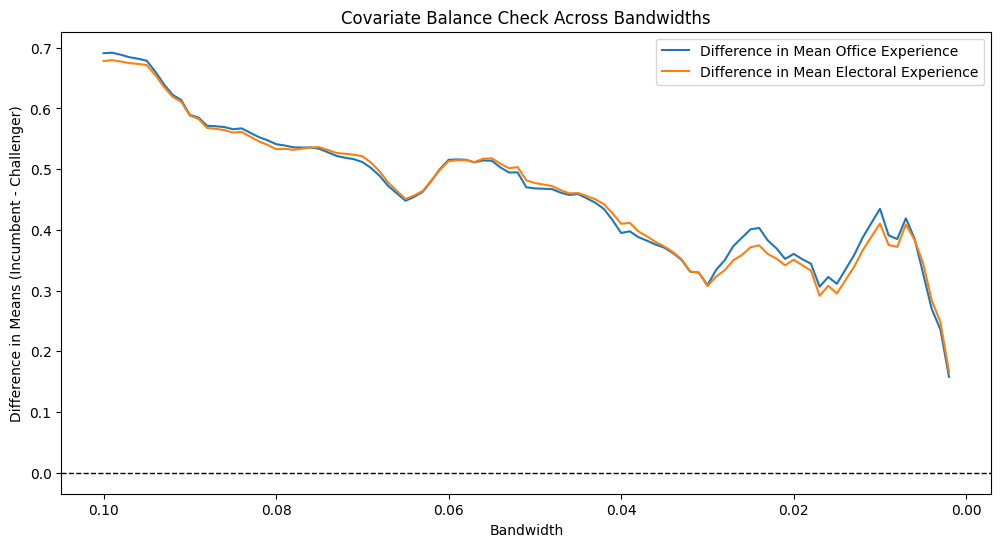

In [290]:
bandwidths = [b / 1000 for b in range(100, 1, -1)]
mofficeexp_means_diff = []
melectexp_means_diff = []
for bandwidth in bandwidths:
    condition = (df_clean['difshare'] >= -bandwidth) & (df_clean['difshare'] <= bandwidth)
    means = df_clean[condition].groupby('myoutcomenext')[['mofficeexp', 'melectexp']].mean()
    mofficeexp_means_diff.append(means.loc[1, 'mofficeexp'] - means.loc[0, 'mofficeexp'])
    melectexp_means_diff.append(means.loc[1, 'melectexp'] - means.loc[0, 'melectexp'])

    

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)
ax.plot(bandwidths, mofficeexp_means_diff, label='Difference in Mean Office Experience')
ax.plot(bandwidths, melectexp_means_diff, label='Difference in Mean Electoral Experience')
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Bandwidth')
ax.set_ylabel('Difference in Means (Incumbent - Challenger)')
ax.set_title('Covariate Balance Check Across Bandwidths')
ax.invert_xaxis()
ax.legend()

## Running variables is continuously distributed

<Axes: ylabel='Density'>

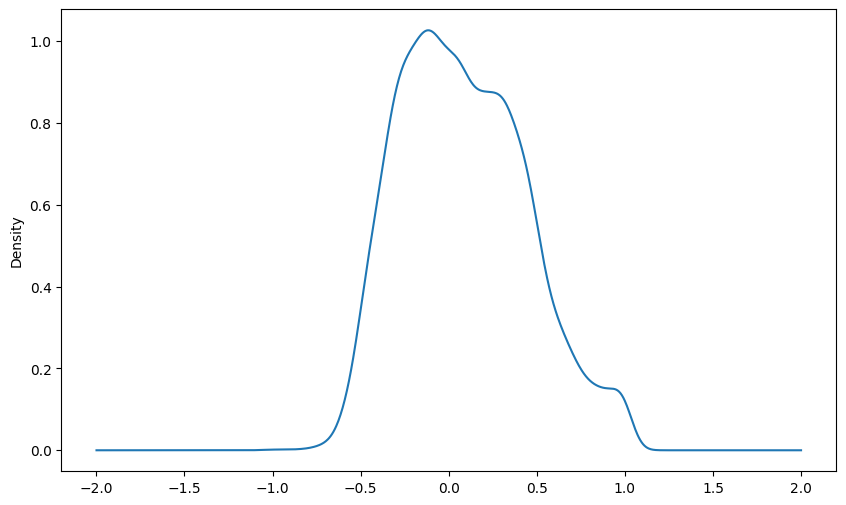

In [292]:
df_clean['difshare'].plot.density(figsize=(10, 6))

# Bibliography

Cunningham, Scott. 2021. Causal Inference: The Mixtape. New Haven: Yale University Press.

Imbens, Guido W., and Thomas Lemieux. 2008. "Regression Discontinuity Designs: A Guide to Practice." Journal of Econometrics 142 (2): 615–635.

Lee, David S. 2008. "Randomized Experiments from Non-random Selection in U.S. House Elections." Journal of Econometrics 142 (2): 675–697.

Thistlethwaite, Donald L., and Donald T. Campbell. 1960. "Regression-Discontinuity Analysis: An Alternative to the Ex Post Facto Experiment." Journal of Educational Psychology 51 (6): 309–317.